In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


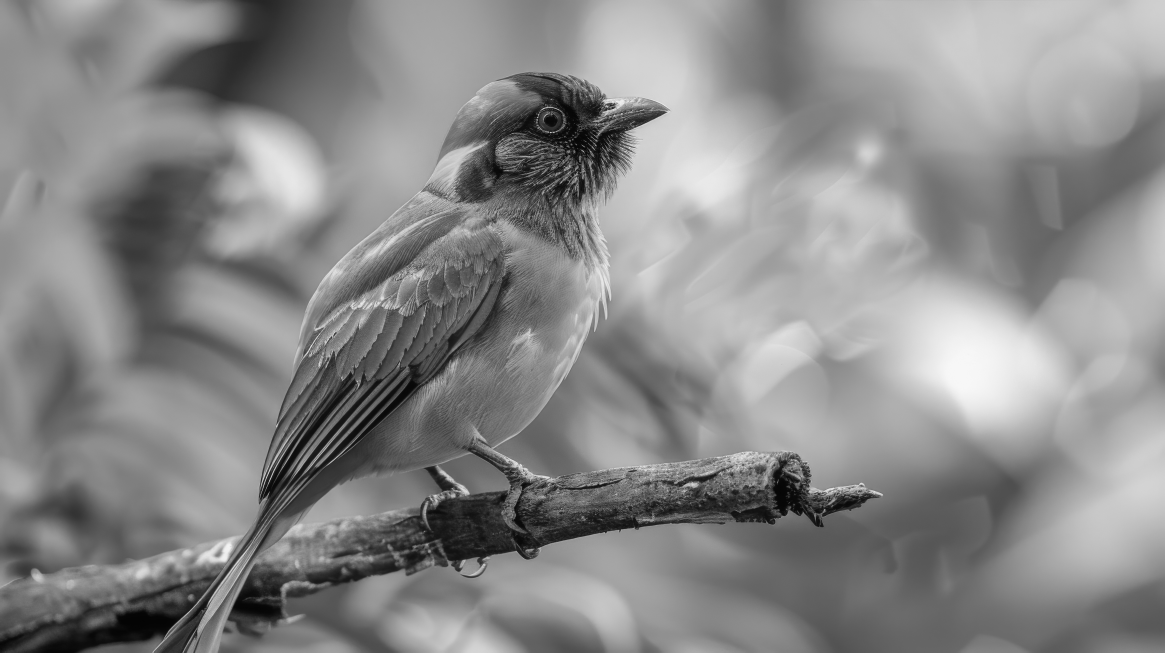

In [14]:
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

image_grayscale = cv2.imread('/content/drive/MyDrive/Sample_Images/BIRD_COLOR.jpeg',  cv2.IMREAD_GRAYSCALE)

# Resize: Scale by a factor
scale_factor = 0.2  # 20% of original
grayscale_image = cv2.resize(image_grayscale, None, fx=scale_factor, fy=scale_factor, interpolation=cv2.INTER_AREA)
cv2_imshow(grayscale_image)

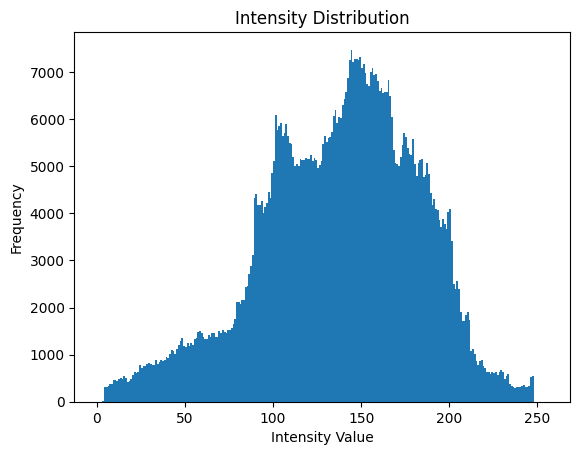

In [15]:
# Display a histogram of the intensity values
plt.hist(grayscale_image.ravel(), bins=256, range=(0, 256))
plt.title('Intensity Distribution')
plt.xlabel('Intensity Value')
plt.ylabel('Frequency')
plt.show()

### **Histogram for Image Segmentation**

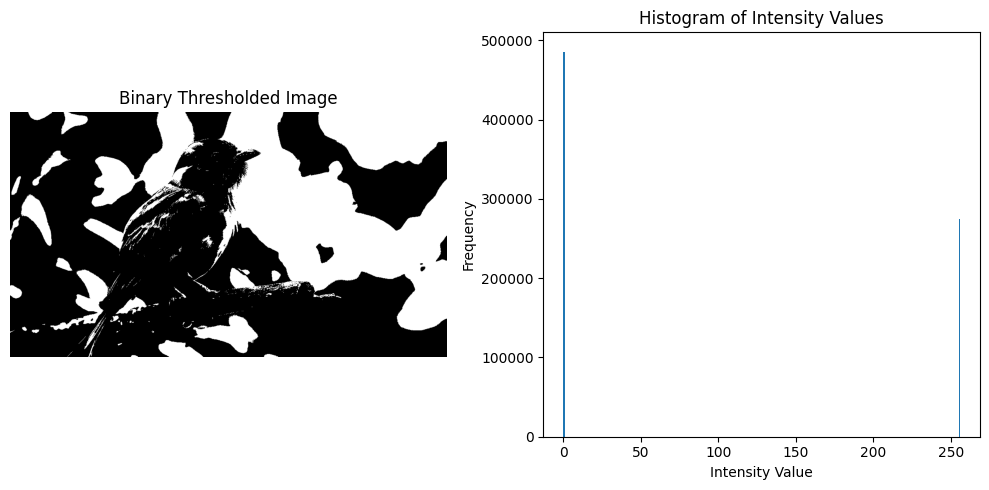

In [25]:
_, binary_thresholded_image = cv2.threshold(grayscale_image, 156, 255, cv2.THRESH_BINARY)

# Mathematical operation done by cv2.threshold:  binary_image(x,y) = { 255  if grayscale(x,y) > 156
#                                                                    {   0  otherwise

plt.figure(figsize=(10, 5))

# Image on left
plt.subplot(1, 2, 1)
plt.imshow(binary_thresholded_image, cmap='gray')
plt.title('Binary Thresholded Image')
plt.axis('off')  # Optional: cleaner look

# Histogram on right
plt.subplot(1, 2, 2)
plt.hist(binary_thresholded_image.ravel(), bins=256, range=[0, 256])
plt.xlabel('Intensity Value')
plt.ylabel('Frequency')
plt.title('Histogram of Intensity Values')

plt.tight_layout()
plt.show()

In [24]:
import numpy as np
hist, _ = np.histogram(binary_thresholded_image, bins=2, range=[0, 256])
background_count = hist[0]  # 0 intensity
foreground_count = hist[1]  # 255 intensity

print(background_count)
print(foreground_count)

# Quality indicators:
foreground_ratio = foreground_count / binary_thresholded_image.size
# Foreground ration measures proportion of image classified as foreground (white pixels). Foreground ration = 0.15 means that 15% of image is foreground

balance_metric = min(foreground_count, background_count) / max(foreground_count, background_count)
# Balance metric measures how evenly distributed the two classes are. Range (0,1). balance_metric = 1.0 means perfect 50/50 split
# balance_metric = 0.1 means 90/10 split (highly imbalanced); balance_metric = 0 means Extreme imbalance (one class dominates)

print(f"Foreground Ratio: {foreground_ratio}")
print(f"Balance Metric: {balance_metric}")

485967
274778
Foreground Ratio: 0.36119593293416324
Balance Metric: 0.5654252243465091


### **Histogram Equalization for Contrast Enhancement**

**Histogram equalization** redistributes pixel intensities to maximize contrast by approximating a uniform distribution across the entire intensity range [0, 255].

**Effect:** Dark regions become darker, bright regions become brighter, mid-tones spread out → increased global contrast.

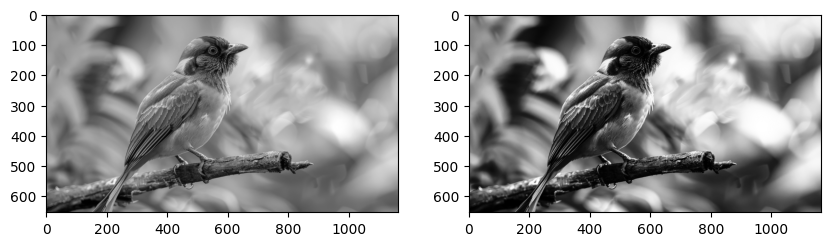

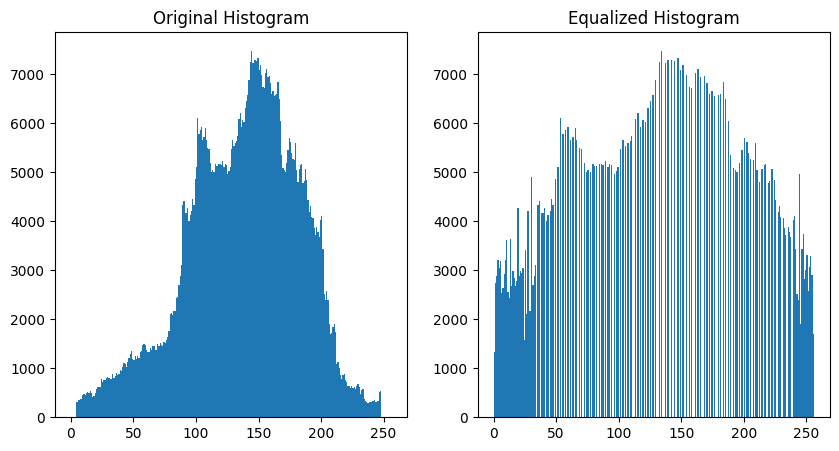

In [26]:
# Apply Histogram Equalization
equalized_image = cv2.equalizeHist(grayscale_image)

# Display original and equalized image
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(grayscale_image, cmap='gray')
plt.subplot(1, 2, 2)
plt.imshow(equalized_image, cmap='gray')
plt.show()

# Display original and equalized histograms
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.hist(grayscale_image.ravel(), bins=256, range=(0, 256))
plt.title('Original Histogram')
plt.subplot(1, 2, 2)
plt.hist(equalized_image.ravel(), bins=256, range=(0, 256))
plt.title('Equalized Histogram')
plt.show()

**When This Works Well**

**Effective scenarios:**

Low contrast images (narrow histogram)

Underexposed/overexposed images

Medical imaging (X-rays, CT scans)

Satellite imagery